**EX NO 4 - TRANSFER LEARNING USING PRE-TRAINED VISION MODELS FOR IMAGE RECOGNITION**

***-VETTRI SELVAN D (24BAD127)***

**AIM**

To implement transfer learning using pre-trained vision models for image recognition and evaluate their performance on real-world image datasets.


**SOFTWARE REQUIREMENTS**

•	Python

•	TensorFlow/Keras or PyTorch

•	Google Colab

•	Hugging Face Transformers

•	Kaggle Dataset

•	Matplotlib

•	GitHub


**OBJECTIVES**

Students will be able to:

•	Understand the concept of transfer learning.

•	Apply pre-trained vision models for image recognition.

•	Fine-tune models such as ResNet or AlexNet.

•	Utilize Kaggle datasets and Hugging Face vision models.

•	Compare transfer learning performance with custom CNN models.


**Task A: DATASET PREPARATION**
Perform the following tasks:

•	Download an image dataset from Kaggle.

•	Load and preprocess the images.

•	Split the dataset into training, validation, and testing sets.


**Task B: IMPLEMENTING TRANSFER LEARNING**

Load a pre-trained model such as:

•	ResNet-50

•	AlexNet

Replace the final classification layer according to the dataset classes.

Freeze the feature extraction layers.

Compile the model.

**Task C: MODEL TRAINING AND PERFORMANCE EVALUATION**

Train the transfer learning model.
Record:

•	Training accuracy

•	Validation accuracy

•	Training loss

•	Validation loss

•	Test accuracy

Visualize:

•	Accuracy vs Epoch

•	Loss vs Epoch


**Task D: USING HUGGING FACE PRE-TRAINED MODELS**

Perform the following tasks:

•	Load a pre-trained vision model from Hugging Face.

•	Perform image classification on sample images.

•	Compare predictions with the transfer learning model.

•	Document observations and upload the notebook to GitHub.


INSTALL & IMPORT

In [1]:
print("VETTRI SELVAN - 24BAD127")
print("TRANSFER LEARNING USING PRE-TRAINED VISION MODELS")

!pip install -q transformers

import os
import zipfile
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from PIL import Image
from tensorflow.keras import layers, models
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input

print("TensorFlow Version:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

VETTRI SELVAN - 24BAD127
TRANSFER LEARNING USING PRE-TRAINED VISION MODELS
TensorFlow Version: 2.20.0
GPU: []


DOWNLOAD DATASET

In [2]:
!wget -q -O /content/dataset.zip \
https://www.kaggle.com/api/v1/datasets/download/bhavikjikadara/dog-and-cat-classification-dataset

print("Kaggle dataset downloaded successfully!")

Kaggle dataset downloaded successfully!


EXTRACT DATASET

In [3]:
os.makedirs("/content/dataset", exist_ok=True)

with zipfile.ZipFile("/content/dataset.zip", "r") as zip_ref:
    zip_ref.extractall("/content/dataset")

print("Dataset extracted successfully!")

Dataset extracted successfully!


FIND DATASET STRUCTURE

In [4]:
print("Dataset folders containing images:\n")

for root, dirs, files in os.walk("/content/dataset"):

    image_count = sum(
        f.lower().endswith((".jpg", ".jpeg", ".png"))
        for f in files
    )

    if image_count > 0:
        print(root, "->", image_count, "images")

Dataset folders containing images:

/content/dataset/PetImages/Cat -> 12499 images
/content/dataset/PetImages/Dog -> 12499 images


SET CORRECT DATASET PATH

In [5]:
DATASET_PATH = "/content/dataset/PetImages"

print("Dataset Path:", DATASET_PATH)

Dataset Path: /content/dataset/PetImages


REMOVE INVALID IMAGES




In [6]:
removed = 0

for root, dirs, files in os.walk(DATASET_PATH):

    for file in files:

        if file.lower().endswith((".jpg", ".jpeg", ".png")):

            path = os.path.join(root, file)

            try:
                with Image.open(path) as img:
                    img.verify()

                with Image.open(path) as img:
                    img.convert("RGB")

            except Exception:

                print("Removing invalid image:", path)

                try:
                    os.remove(path)
                    removed += 1
                except:
                    pass

print("\nInvalid images removed:", removed)
print("Dataset cleaning completed!")

/usr/local/lib/python3.13/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))



Invalid images removed: 0
Dataset cleaning completed!


RELOAD DATASET

In [7]:
IMG_SIZE = (128, 128)
BATCH_SIZE = 32
SEED = 42

train_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.30,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode="rgb"
)

temp_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.30,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode="rgb"
)

class_names = train_ds.class_names

print("Classes:", class_names)
print("Number of Classes:", len(class_names))

Found 24998 files belonging to 2 classes.
Using 17499 files for training.
Found 24998 files belonging to 2 classes.
Using 7499 files for validation.
Classes: ['Cat', 'Dog']
Number of Classes: 2


CREATE VALIDATION + TEST SET

In [8]:
total_batches = tf.data.experimental.cardinality(temp_ds).numpy()

test_batches = total_batches // 2

test_ds = temp_ds.take(test_batches)
val_ds = temp_ds.skip(test_batches)

print("Training batches:",
      tf.data.experimental.cardinality(train_ds).numpy())

print("Validation batches:",
      tf.data.experimental.cardinality(val_ds).numpy())

print("Testing batches:",
      tf.data.experimental.cardinality(test_ds).numpy())

Training batches: 547
Validation batches: 118
Testing batches: 117


RECREATE RESNET-50 MODEL

In [9]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

print("Data pipeline ready!")

Data pipeline ready!


SAMPLE IMAGES

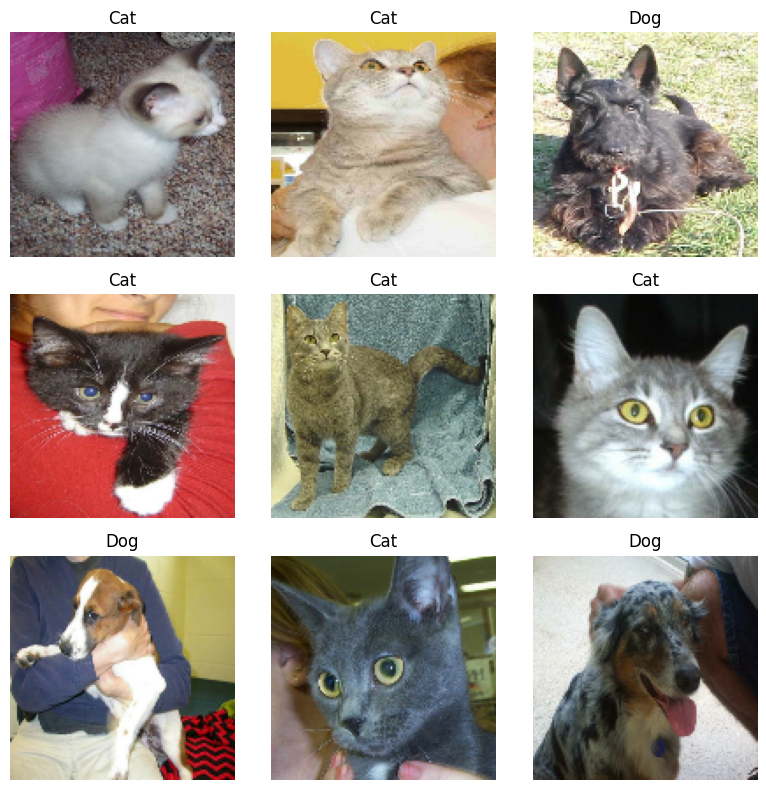

In [10]:
plt.figure(figsize=(8, 8))

for images, labels in train_ds.take(1):

    for i in range(9):

        ax = plt.subplot(3, 3, i + 1)

        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.tight_layout()
plt.show()

RESNET

In [11]:
base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(128, 128, 3)
)

base_model.trainable = False

print("ResNet-50 loaded successfully!")
print("Feature extraction layers:", len(base_model.layers))

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
ResNet-50 loaded successfully!
Feature extraction layers: 175


MODEL SUMMARY

In [12]:
num_classes = len(class_names)

model = models.Sequential([

    layers.Input(shape=(128, 128, 3)),

    layers.Lambda(preprocess_input),

    base_model,

    layers.GlobalAveragePooling2D(),

    layers.Dropout(0.2),

    layers.Dense(
        num_classes,
        activation="softmax"
    )
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lambda (Lambda)                 │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 4, 4, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 2)              │         4,098 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,591,810 (90.00 MB)

 Trainable params: 4,098 (16.01 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

MODEL COMPILATION

In [13]:
model.compile(

    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.0001
    ),

    loss="sparse_categorical_crossentropy",

    metrics=["accuracy"]
)

print("Model compiled successfully!")

Model compiled successfully!


CLEAN AND CONVERT ALL IMAGES

In [14]:
import os
from PIL import Image

DATASET_PATH = "/content/dataset/PetImages"

fixed = 0
removed = 0

for root, dirs, files in os.walk(DATASET_PATH):

    for file in files:

        if not file.lower().endswith((".jpg", ".jpeg", ".png")):
            continue

        path = os.path.join(root, file)

        try:
            img = Image.open(path)

            # Convert every image to RGB
            img = img.convert("RGB")

            # Save back as a normal RGB JPEG
            new_path = os.path.splitext(path)[0] + ".jpg"

            img.save(new_path, "JPEG")

            # Remove original if extension was different
            if new_path != path:
                os.remove(path)

            fixed += 1

        except Exception as e:
            print("Removing:", path)
            try:
                os.remove(path)
                removed += 1
            except:
                pass

print("Images converted to RGB:", fixed)
print("Invalid images removed:", removed)
print("Dataset cleaning completed!")

Images converted to RGB: 24998
Invalid images removed: 0
Dataset cleaning completed!


CHECK CLASSES

In [15]:
print("Folders inside dataset:")

for item in os.listdir(DATASET_PATH):
    full_path = os.path.join(DATASET_PATH, item)

    if os.path.isdir(full_path):
        count = len([
            f for f in os.listdir(full_path)
            if f.lower().endswith(".jpg")
        ])

        print(item, "->", count, "images")


Folders inside dataset:
Cat -> 12499 images
Dog -> 12499 images


RECREATE DATASET

In [16]:
import tensorflow as tf

IMG_SIZE = (128, 128)
BATCH_SIZE = 32
SEED = 42

train_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.30,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode="rgb"
)

temp_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.30,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode="rgb"
)

class_names = train_ds.class_names

print("Classes:", class_names)
print("Number of Classes:", len(class_names))

Found 24998 files belonging to 2 classes.
Using 17499 files for training.
Found 24998 files belonging to 2 classes.
Using 7499 files for validation.
Classes: ['Cat', 'Dog']
Number of Classes: 2


SPLIT VALIDATION/TEST

In [17]:
total_batches = tf.data.experimental.cardinality(temp_ds).numpy()

test_batches = total_batches // 2

test_ds = temp_ds.take(test_batches)
val_ds = temp_ds.skip(test_batches)

print("Training batches:",
      tf.data.experimental.cardinality(train_ds).numpy())

print("Validation batches:",
      tf.data.experimental.cardinality(val_ds).numpy())

print("Testing batches:",
      tf.data.experimental.cardinality(test_ds).numpy())

Training batches: 547
Validation batches: 118
Testing batches: 117


RECREATE RESNET-50

In [18]:
from tensorflow.keras import layers, models
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input

base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(128, 128, 3)
)

base_model.trainable = False

model = models.Sequential([
    layers.Input(shape=(128, 128, 3)),
    layers.Lambda(preprocess_input),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.2),
    layers.Dense(
        len(class_names),
        activation="softmax"
    )
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(0.0001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("ResNet-50 model ready!")

ResNet-50 model ready!


FAST TRAINING

In [19]:
EPOCHS = 1

FAST_TRAIN = train_ds.take(10)
FAST_VAL = val_ds.take(3)

history = model.fit(
    FAST_TRAIN,
    validation_data=FAST_VAL,
    epochs=EPOCHS
)

10/10 ━━━━━━━━━━━━━━━━━━━━ 24s 2s/step - accuracy: 0.5281 - loss: 1.3972 - val_accuracy: 0.5729 - val_loss: 1.1069


ACCURACY VS EPOCH

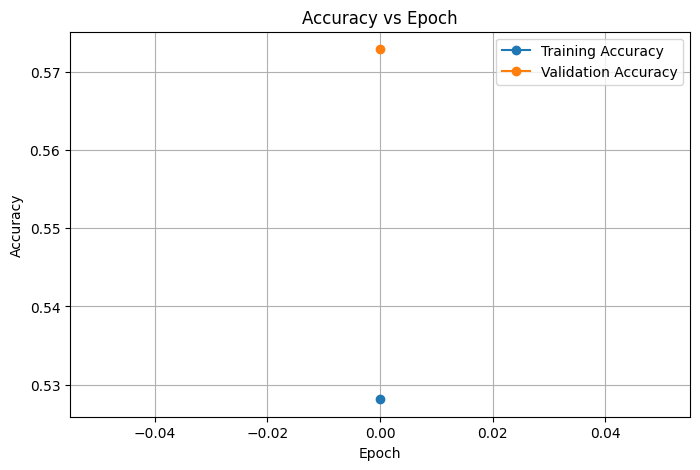

In [20]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    marker="o",
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Epoch")
plt.legend()
plt.grid()

plt.show()

LOSS VS EPOCH

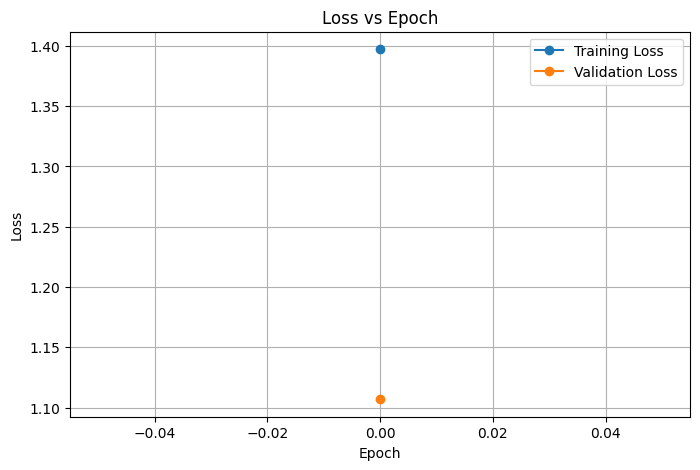

In [21]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    marker="o",
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss vs Epoch")
plt.legend()
plt.grid()

plt.show()

TEST ACCURACY

In [22]:
test_loss, test_accuracy = model.evaluate(
    test_ds,
    verbose=1
)

print("Test Loss     :", round(test_loss, 4))
print("Test Accuracy :", round(test_accuracy, 4))

117/117 ━━━━━━━━━━━━━━━━━━━━ 142s 1s/step - accuracy: 0.5777 - loss: 0.9712
Test Loss     : 0.9712
Test Accuracy : 0.5777


SAMPLE IMAGE PREDICTION

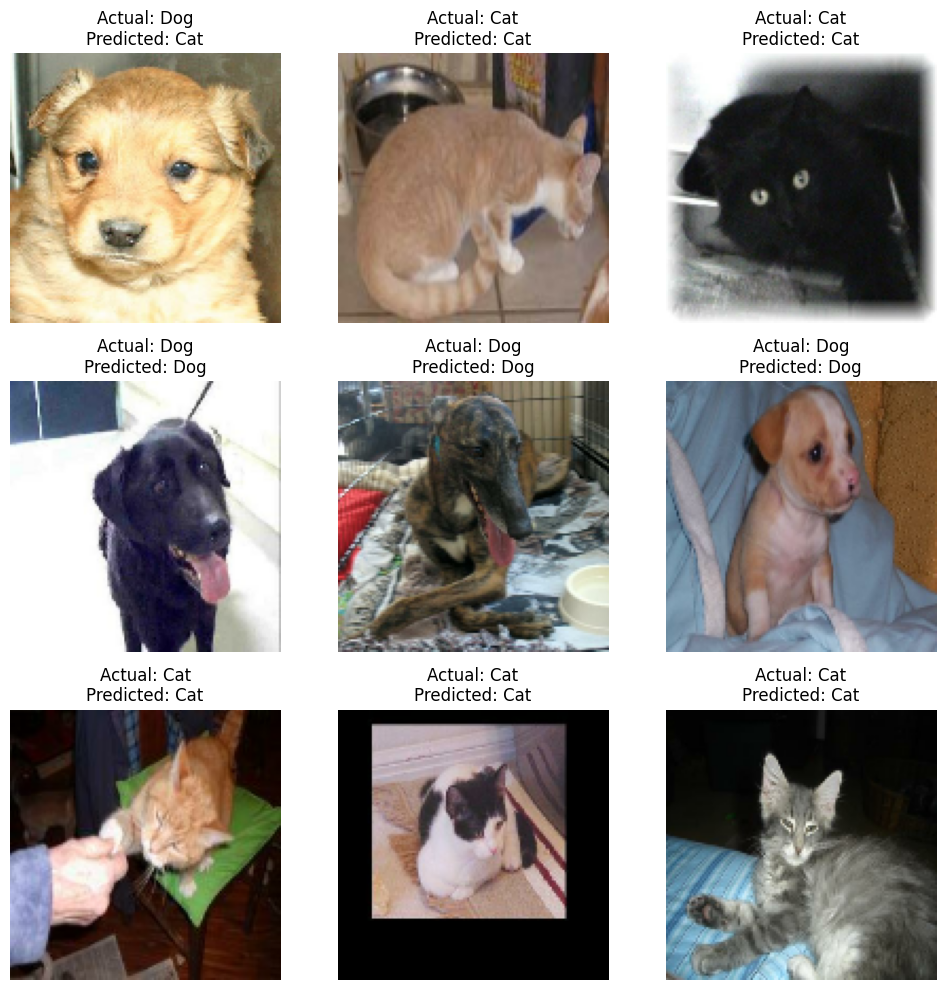

In [23]:
plt.figure(figsize=(10, 10))

for images, labels in test_ds.take(1):

    predictions = model.predict(
        images,
        verbose=0
    )

    predicted_classes = np.argmax(
        predictions,
        axis=1
    )

    for i in range(min(9, len(images))):

        ax = plt.subplot(3, 3, i + 1)

        plt.imshow(
            images[i].numpy().astype("uint8")
        )

        actual = class_names[labels[i]]
        predicted = class_names[predicted_classes[i]]

        plt.title(
            f"Actual: {actual}\nPredicted: {predicted}"
        )

        plt.axis("off")

plt.tight_layout()
plt.show()

TASK D — HUGGING FACE

LOAD HUGGING FACE MODEL

In [24]:
from transformers import pipeline

classifier = pipeline(
    "image-classification",
    model="google/vit-base-patch16-224"
)

print("Hugging Face Vision Model Loaded Successfully!")

config.json:   0%|          | 0.00/69.7k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  346MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

Hugging Face Vision Model Loaded Successfully!


HUGGING FACE PREDICTION

In [25]:
from PIL import Image

for images, labels in test_ds.take(1):

    sample_image = images[0].numpy().astype("uint8")
    actual_label = class_names[labels[0]]

sample_pil = Image.fromarray(sample_image)

hf_prediction = classifier(sample_pil)

print("Actual Class:", actual_label)

print("\nHugging Face Predictions:")

for result in hf_prediction[:5]:

    print(
        result["label"],
        "->",
        round(result["score"], 4)
    )

Actual Class: Dog

Hugging Face Predictions:
Staffordshire bullterrier, Staffordshire bull terrier -> 0.7307
American Staffordshire terrier, Staffordshire terrier, American pit bull terrier, pit bull terrier -> 0.2353
boxer -> 0.0153
bull mastiff -> 0.0017
French bulldog -> 0.0016


MODEL COMPARISON

In [26]:
tf_prediction = model.predict(
    np.expand_dims(sample_image, axis=0),
    verbose=0
)

tf_class_index = np.argmax(tf_prediction[0])

tf_class = class_names[tf_class_index]

print("MODEL COMPARISON")
print("Actual Class:", actual_label)

print(
    "ResNet-50 Transfer Learning:",
    tf_class
)

print("\nHugging Face Top Prediction:")

print(
    hf_prediction[0]["label"],
    "->",
    round(hf_prediction[0]["score"], 4)
)

MODEL COMPARISON
Actual Class: Dog
ResNet-50 Transfer Learning: Cat

Hugging Face Top Prediction:
Staffordshire bullterrier, Staffordshire bull terrier -> 0.7307


FINAL RESULTS

In [27]:
train_accuracy = history.history["accuracy"][-1]
val_accuracy = history.history["val_accuracy"][-1]

print("FINAL RESULTS")

print(
    "Training Accuracy   :",
    round(train_accuracy, 4)
)

print(
    "Validation Accuracy :",
    round(val_accuracy, 4)
)

print(
    "Test Accuracy       :",
    round(test_accuracy, 4)
)

print(
    "Test Loss           :",
    round(test_loss, 4)
)

FINAL RESULTS
Training Accuracy   : 0.5281
Validation Accuracy : 0.5729
Test Accuracy       : 0.5777
Test Loss           : 0.9712


SAVE MODEL

In [28]:
model.save(
    "/content/resnet50_transfer_learning.keras"
)

print("ResNet-50 Transfer Learning Model Saved Successfully!")

ResNet-50 Transfer Learning Model Saved Successfully!
